In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [1649]:
import random

random.seed(42)

In [1650]:
routes = pd.read_csv("../data/raw/route.csv")

In [1651]:
G = nx.DiGraph()

In [1652]:
# bus stops
stop_map = {
    # "หอพักเอเชียนเกม (B Zone)": "Dorm",
    "หอพักเอเชียนเกม": "Dorm",
    "green": "Green",
    "SC2 SC3": "SC2_SC3",
    "อาคารสุขศาสตร์": "Health",
    # "อาคารบรรยายรวม 4": "Lecture",
    "อาคารบรรยายรวม": "Lecture",
    "ศูนย์ประชุม": "Convention",
    "สถานีขนส่ง": "Terminal",
    "หอสมุดป๋วย": "Library",
    "รพ.ธรรมศาสตร์": "Hospital",
    "อุทยานการเรียนรู้ป๋วย 100 ปี": "Park",
    # "อาคารบรรยายรวม 3": "Lecture3",
    # "อาคารบรรยายรวม 1": "Lecture1",
    "TU DOME": "Dome",
    "ประตูเชียงราก 1": "Gate1",
    "SC1": "SC1",
    "อาคารเรียนรวมกลุ่มสังคมศาสตร์": "Social"
}

stops = list(set(stop_map.values()))
G.add_nodes_from(stops)


### Candidate Routes

In [1653]:
# Candidate Stops
candidate_stops = [
    "Dorm",
    "Green",
    "SC2_SC3",
    "Health",
    "Lecture"
] #ตอนนี้จำลองมาแค่ สายเสริมพิเศษ

### Convert KM to Minute

In [1654]:
def km_to_min(km):
    return round(km * 3)  # 20 km/h

# เสริมพิเศษ
G.add_edge("Dorm", "Green", weight=km_to_min(1.2))
G.add_edge("Green", "SC2_SC3", weight=km_to_min(0.6))
G.add_edge("SC2_SC3", "Health", weight=km_to_min(1.0))
G.add_edge("Health", "Lecture", weight=km_to_min(0.5))
G.add_edge("Lecture", "Dorm", weight=km_to_min(1.9))

# สีแดง 1A
G.add_edge("Convention", "Terminal", weight=km_to_min(1.1))
G.add_edge("Terminal", "SC2_SC3", weight=km_to_min(0.65))
G.add_edge("SC2_SC3", "Library", weight=km_to_min(0.6))
G.add_edge("Library", "Dorm", weight=km_to_min(1.5))
G.add_edge("Dorm", "Convention", weight=km_to_min(3.6))

# สีเหลือง 1B
G.add_edge("Convention", "Dorm", weight=km_to_min(3.6))
G.add_edge("Dorm", "Library", weight=km_to_min(1.5))
G.add_edge("Library", "SC2_SC3", weight=km_to_min(0.6))
G.add_edge("SC2_SC3", "Terminal", weight=km_to_min(0.65))
G.add_edge("Terminal", "Convention", weight=km_to_min(1.1))

# สีเขียว 2
G.add_edge("Convention", "Hospital", weight=km_to_min(0.7))
G.add_edge("Hospital", "Health", weight=km_to_min(0.5))
G.add_edge("Health", "Park", weight=km_to_min(0.1))
G.add_edge("Park", "Lecture", weight=km_to_min(0.28))
# G.add_edge("Lecture", "Lecture3", weight=km_to_min(0.22))
# G.add_edge("Lecture3", "Lecture1", weight=km_to_min(0.45))
G.add_edge("Lecture", "Convention", weight=3)  # สมมติ

# สีม่วง 3
G.add_edge("Dome", "Gate1", weight=3)
G.add_edge("Gate1", "SC1", weight=3)
G.add_edge("SC1", "Library", weight=3)
G.add_edge("Library", "Green", weight=3)
G.add_edge("Green", "Dorm", weight=3)

# สีฟ้า 5
G.add_edge("Convention", "Social", weight=3)
G.add_edge("Social", "Lecture", weight=3)
G.add_edge("Lecture", "Park", weight=3)
G.add_edge("Park", "Health", weight=3)
G.add_edge("Health", "Hospital", weight=3)

### Bidirectional

In [1655]:
edges = list(G.edges(data=True))

for u, v, data in edges:
    G.add_edge(v, u, weight=data["weight"])

In [1656]:
# Single Candidate Routes
def generate_single_candidate_route(
    graph,
    start="Dorm",
    min_length=4,
    max_length=6
):
    """
    สร้าง route แบบ loop
    start -> ... -> start
    """
    route = [start]
    current = start
    route_length = random.randint(min_length, max_length)

    while len(route) < route_length:
        neighbors = list(graph.neighbors(current))
        # หลีกเลี่ยงการวนซ้ำมั่ว
        valid_neighbors = [
            n for n in neighbors
            if n not in route[:-1]
        ]

        if not valid_neighbors:
            break
        next_stop = random.choice(valid_neighbors)
        route.append(next_stop)
        current = next_stop
    # ปิด loop กลับจุดเริ่มต้น

    if route[-1] != start:
        if graph.has_edge(route[-1], start):
            route.append(start)
        else:
            try:
                path_back = nx.shortest_path(
                    graph,
                    source=route[-1],
                    target=start,
                    weight="weight"
                )
                route.extend(path_back[1:])
            except:
                route.append(start)
    return route

In [1657]:
# MANY Candidate Routes
def generate_candidate_routes(
    graph,
    num_routes=20
):
    candidate_routes = []

    important_stops = [

        "Dorm",

        "Lecture",

        "Library",

        "Convention",

        "Terminal",

        "Hospital"

    ]

    for i in range(num_routes):

        start = random.choice(important_stops)

        end = random.choice(important_stops)

        while start == end:

            end = random.choice(important_stops)

        try:

            path = nx.shortest_path(

                G,
                source=start,
                target=end,
                weight="weight"
            )

            # ทำให้เป็น loop route

            if path[-1] != path[0]:

                path.append(path[0])

            route = {

                "route_id": i + 1,

                "path": path,

                "cycle_time": len(path),

            }

            candidate_routes.append(route)

        except:

            continue

    return candidate_routes

In [1658]:
candidate_routes = generate_candidate_routes(
    G,
    num_routes=20
)
print("===== Candidate Routes =====")
for i, route in enumerate(candidate_routes):
    
    print(f" {i+1}: {route}")

===== Candidate Routes =====
 1: {'route_id': 1, 'path': ['Hospital', 'Health', 'Lecture', 'Dorm', 'Hospital'], 'cycle_time': 5}
 2: {'route_id': 2, 'path': ['Dorm', 'Green', 'SC2_SC3', 'Health', 'Hospital', 'Dorm'], 'cycle_time': 6}
 3: {'route_id': 3, 'path': ['Library', 'SC2_SC3', 'Health', 'Lecture', 'Library'], 'cycle_time': 5}
 4: {'route_id': 4, 'path': ['Lecture', 'Health', 'Hospital', 'Lecture'], 'cycle_time': 4}
 5: {'route_id': 5, 'path': ['Dorm', 'Green', 'SC2_SC3', 'Health', 'Hospital', 'Dorm'], 'cycle_time': 6}
 6: {'route_id': 6, 'path': ['Hospital', 'Convention', 'Terminal', 'Hospital'], 'cycle_time': 4}
 7: {'route_id': 7, 'path': ['Dorm', 'Green', 'SC2_SC3', 'Terminal', 'Dorm'], 'cycle_time': 5}
 8: {'route_id': 8, 'path': ['Convention', 'Lecture', 'Dorm', 'Convention'], 'cycle_time': 4}
 9: {'route_id': 9, 'path': ['Dorm', 'Lecture', 'Dorm'], 'cycle_time': 3}
 10: {'route_id': 10, 'path': ['Lecture', 'Convention', 'Terminal', 'Lecture'], 'cycle_time': 4}
 11: {'route

### Route for simulation

In [1659]:
route_special = ["Dorm", "Green", "SC2_SC3", "Health", "Lecture", "Dorm"]
route_red = ["Convention", "Terminal", "SC2_SC3", "Library", "Dorm", "Convention"]
route_yellow = ["Convention", "Dorm", "Library", "SC2_SC3", "Terminal", "Convention"]
route_purple = ["Dome", "Gate1", "SC1", "Library", "Green", "Dorm"]
route_blue = ["Convention", "Social", "Lecture", "Park", "Health", "Hospital"]
route_green = ["Convention", "Hospital", "Health", "Park", "Lecture", "Convention"]

### Bus Object Class

In [1660]:
class Bus:
    def __init__(self, id, capacity, route):
        self.id = id
        self.capacity = capacity
        self.route = route
        self.current_index = 0   # อยู่ป้ายไหน
        self.passengers = []

### Define Buses

In [1661]:
buses = [
    Bus(0, 30, route_special),
    Bus(1, 30, route_red),
    Bus(2, 30, route_yellow),
    Bus(3, 30, route_purple),
    Bus(4, 30, route_blue),
    Bus(5, 30, route_green),
]

### Passenger Model

In [1662]:
class Passenger:
    def __init__(self, origin, destination, arrival_time):
        self.origin = origin
        self.destination = destination
        self.arrival_time = arrival_time

### Queue

In [1663]:
queues = {
    "Dorm": [],
    "Green": [],
    "SC2_SC3": [],
    "Health": [],
    "Lecture": [],
    "Terminal" : [],
    "Convention" : [],
    "Library" : [],
    "SC1" : [],
    "Gate1" : [],
    "Hospital" : [],
    "Social" : [],
    "Park" : [],
    "Dome" : []
}

In [1664]:
TOTAL_BUSES = 20          # รถรวมทั้งหมด
MIN_ROUTE_BUS = [1, 1, 1, 1, 1, 1]   # route 0 ต้องมีอย่างน้อย 1 คัน
MAX_PER_ROUTE = 5
MIN_PER_ROUTE = 1
SELECTED_ROUTES = 6 

In [1665]:
def repair(chromosome):

    used = set()

    repaired = []

    for gene in chromosome:

        rid = gene["route_id"]

        if rid not in used:

            used.add(rid)

            repaired.append({

                "route_id": rid,

                "path": gene["path"],  # สำคัญมาก

                "num_bus": max(

                    MIN_PER_ROUTE,

                    min(

                        MAX_PER_ROUTE,

                        gene["num_bus"]

                    )

                )

            })

    # ---------------------------------

    # 2. route ไม่ครบ → เติมเพิ่ม

    # ---------------------------------

    available_routes = [

        route for route in candidate_routes

        if route["route_id"] not in used

    ]

    while len(repaired) < SELECTED_ROUTES:

        route = random.choice(

            available_routes

        )

        available_routes.remove(route)

        repaired.append({

            "route_id": route["route_id"],

            "path": route["path"],   # สำคัญมาก

            "num_bus": MIN_PER_ROUTE

        })

    # ---------------------------------

    # 3. route เกิน → ตัดออก

    # ---------------------------------

    while len(repaired) > SELECTED_ROUTES:

        repaired.pop()

    # ---------------------------------

    # 4. total buses = TOTAL_BUSES

    # ---------------------------------

    current_total = sum(

        g["num_bus"]

        for g in repaired

    )

    while current_total < TOTAL_BUSES:

        idx = random.randint(

            0,

            len(repaired) - 1

        )

        if repaired[idx]["num_bus"] < MAX_PER_ROUTE:

            repaired[idx]["num_bus"] += 1

            current_total += 1

    while current_total > TOTAL_BUSES:

        idx = random.randint(

            0,

            len(repaired) - 1

        )

        if repaired[idx]["num_bus"] > MIN_PER_ROUTE:

            repaired[idx]["num_bus"] -= 1

            current_total -= 1

    return repaired

In [1666]:
def random_chromosome():
    """
    chromosome format:

    [
        {
            "route_id": 3,
            "path": [...],
            "num_bus": 4
        }
    ]
    """

    # สุ่มเลือก route จริงจาก candidate_routes
    selected_routes = random.sample(
        candidate_routes,
        SELECTED_ROUTES
    )

    chromosome = []

    for route in selected_routes:

        chromosome.append({
            "route_id": route["route_id"],

            # สำคัญมาก
            "path": route["path"],

            "num_bus": random.randint(
                MIN_PER_ROUTE,
                MAX_PER_ROUTE
            )
        })

    chromosome = repair(chromosome)

    return chromosome

In [1667]:
def calculate_cycle_time(route_path, graph):
    """
    คำนวณเวลาเดินทางรวมของ route
    โดยใช้ weight จาก graph
    """
    total_time = 0
    for i in range(len(route_path) - 1):
        current_stop = route_path[i]
        next_stop = route_path[i + 1]
        try:
            edge_time = graph[current_stop][next_stop]["weight"]
            total_time += edge_time
        except:
            # ถ้าไม่มี edge โดยตรง
            # ใช้ shortest path แทน
            try:

                shortest_time = nx.shortest_path_length(

                    graph,

                    source=current_stop,

                    target=next_stop,

                    weight="weight"

                )

                total_time += shortest_time

            except:

                # กัน graph error

                total_time += 999

    return total_time

def build_active_routes(chromosome, candidate_routes, graph):
    active_routes = []

    for gene in chromosome:
        route_id = gene["route_id"]
        num_bus = gene["num_bus"]

        # หา route จาก candidate_routes
        route_data = next(
            (
                r for r in candidate_routes
                if r["route_id"] == route_id
            ),
            None
        )

        # ถ้าไม่เจอ → ข้าม
        if route_data is None:
            print(f"WARNING: route_id {route_id} not found")
            continue

        route_path = route_data["path"]

        cycle_time = calculate_cycle_time(
            route_path,
            graph
        )

        headway = cycle_time / num_bus

        active_routes.append({
            "route_id": route_id,
            "path": route_path,
            "num_bus": num_bus,
            "cycle_time": cycle_time,
            "headway": round(headway, 2)
        })

    return active_routes
      

# =========================================

# TEST

# =========================================

print("===== ACTIVE ROUTES =====")

# random chromosome จาก STEP 2

test_chromosome = random_chromosome()

active_routes = build_active_routes(

    test_chromosome,

    candidate_routes,

    G

)

for route in active_routes:

    print(route)

===== ACTIVE ROUTES =====
{'route_id': 4, 'path': ['Lecture', 'Health', 'Hospital', 'Lecture'], 'num_bus': 2, 'cycle_time': 8, 'headway': 4.0}
{'route_id': 3, 'path': ['Library', 'SC2_SC3', 'Health', 'Lecture', 'Library'], 'num_bus': 5, 'cycle_time': 14, 'headway': 2.8}
{'route_id': 13, 'path': ['Hospital', 'Convention', 'Terminal', 'Hospital'], 'num_bus': 3, 'cycle_time': 10, 'headway': 3.33}
{'route_id': 20, 'path': ['Lecture', 'Health', 'SC2_SC3', 'Library', 'Lecture'], 'num_bus': 1, 'cycle_time': 14, 'headway': 14.0}
{'route_id': 12, 'path': ['Terminal', 'Convention', 'Lecture', 'Terminal'], 'num_bus': 4, 'cycle_time': 12, 'headway': 3.0}
{'route_id': 14, 'path': ['Convention', 'Lecture', 'Convention'], 'num_bus': 5, 'cycle_time': 6, 'headway': 1.2}


### Simulation Loop

In [1668]:
import random

def run_simulation(active_routes, stops, simulation_time=60):

    # =====================================
    # RESET STATE
    # =====================================

    queues = {stop: [] for stop in stops}

    waiting_times = []
    travel_times = []
    queue_lengths = []

    buses = []
    bus_id = 0

    # =====================================
    # CREATE BUSES FROM ACTIVE ROUTES
    # =====================================

    for route_info in active_routes:
        route_path = route_info["path"]
        num_bus = route_info["num_bus"]

        for _ in range(num_bus):
            buses.append(
                Bus(
                    id=bus_id,
                    capacity=30,
                    route=route_path
                )
            )
            bus_id += 1

    # =====================================
    # PASSENGER GENERATION
    # =====================================

    def generate_passengers(t):

        # Peak Time Example
        if 10 <= t <= 25:
            demand_prob = 0.8
        else:
            demand_prob = 0.4

        if random.random() < demand_prob:
            origin = random.choice(stops)
            destination = random.choice(stops)

            while destination == origin:
                destination = random.choice(stops)

            p = Passenger(
                origin=origin,
                destination=destination,
                arrival_time=t
            )

            queues[origin].append(p)

    # =====================================
    # MOVE BUS
    # =====================================

    def move_bus(bus):
        bus.current_index += 1

        if bus.current_index >= len(bus.route):
            bus.current_index = 0

    # =====================================
    # DROP PASSENGERS
    # =====================================

    def drop_passengers(bus, t):
        current_stop = bus.route[bus.current_index]

        remaining = []

        for p in bus.passengers:
            if p.destination == current_stop:
                p.drop_time = t

                travel_time = t - p.arrival_time
                travel_times.append(travel_time)

            else:
                remaining.append(p)

        bus.passengers = remaining

    # =====================================
    # BOARD PASSENGERS
    # =====================================

    def board_passengers(bus, t):
        current_stop = bus.route[bus.current_index]

        if current_stop not in queues:
            return

        queue = queues[current_stop]

        remaining_queue = []

        for p in queue:
            if (
                len(bus.passengers) < bus.capacity
                and p.destination in bus.route
            ):
                p.board_time = t
                bus.passengers.append(p)

                waiting_time = t - p.arrival_time
                waiting_times.append(waiting_time)

            else:
                remaining_queue.append(p)

        queues[current_stop] = remaining_queue

    # =====================================
    # MAIN SIMULATION LOOP
    # =====================================

    for t in range(simulation_time):

        generate_passengers(t)

        for bus in buses:
            move_bus(bus)
            drop_passengers(bus, t)
            board_passengers(bus, t)

        total_queue = sum(len(q) for q in queues.values())
        queue_lengths.append(total_queue)

    # =====================================
    # METRICS
    # =====================================

    avg_wait = (
        sum(waiting_times) / len(waiting_times)
        if waiting_times else 0
    )

    avg_travel = (
        sum(travel_times) / len(travel_times)
        if travel_times else 0
    )

    avg_queue_length = (
        sum(queue_lengths) / len(queue_lengths)
        if queue_lengths else 0
    )

    return {
        "avg_wait_time": round(avg_wait, 2),
        "avg_travel_time": round(avg_travel, 2),
        "avg_queue_length": round(avg_queue_length, 2),
        "served_passengers": len(travel_times)
    }

In [1669]:
routes_test = [
    {'route_id': 5, 'path': ['Dorm', 'Lecture', 'Social', 'Convention', 'Dorm'], 'num_bus': 1, 'cycle_time': 4, 'headway': 4.0},
    {'route_id': 13, 'path': ['Dorm', 'Library', 'SC1', 'Gate1', 'SC1', 'Library', 'Dorm'], 'num_bus': 2, 'cycle_time': 6, 'headway': 3.0},
    {'route_id': 6, 'path': ['Dorm', 'Convention', 'Social', 'Lecture', 'Dorm'], 'num_bus': 4, 'cycle_time': 4, 'headway': 1.0},
    {'route_id': 3, 'path': ['Dorm', 'Green', 'SC2_SC3', 'Terminal', 'Convention', 'Dorm'], 'num_bus': 5, 'cycle_time': 5, 'headway': 1.0},
    {'route_id': 2, 'path': ['Dorm', 'Lecture', 'Park', 'Health', 'Hospital', 'Convention', 'Dorm'], 'num_bus': 3, 'cycle_time': 6, 'headway': 2.0},
    {'route_id': 16, 'path': ['Dorm', 'Library', 'Green', 'SC2_SC3', 'Library', 'Dorm'], 'num_bus': 5, 'cycle_time': 5, 'headway': 1.0}
]

stops = [
    "Dorm","Green","SC2_SC3","Health","Lecture",
    "Terminal","Convention","Library","SC1",
    "Gate1","Hospital","Social","Park","Dome"
]

result = run_simulation(routes_test, stops)

print(result)

{'avg_wait_time': 2.67, 'avg_travel_time': 5.67, 'avg_queue_length': 12.58, 'served_passengers': 6}


In [1670]:
wait = result["avg_wait_time"]
travel = result["avg_travel_time"]
queue = result["avg_queue_length"]
served = result["served_passengers"]

norm_wait = wait / 10
norm_travel = travel / 10
norm_queue = queue / 20
norm_served = served / 20

before_score = (
     0.35 * norm_wait
        + 0.15 * norm_travel
        + 0.20 * norm_queue
        - 1.0 * norm_served
)
print(before_score)

0.004300000000000026


## Genetic Algorithm (GA)

In [1671]:
# Initial GA Params
POPULATION_SIZE = 20
ELITE_SIZE = 2
CROSSOVER_RATE = 0.8
MUTATION_RATE = 0.1
GENERATIONS = 30

In [1672]:
print("===== RANDOM CHROMOSOME =====")

ch = random_chromosome()

for gene in ch:

    rid = gene["route_id"]

    buses = gene["num_bus"]
    route_data = next(

        r for r in candidate_routes

        if r["route_id"] == rid

    )

    print(

        f"Route ID: {rid} | "

        f"Num Bus: {buses} | "

        f"Path: {route_data['path']}"

    )

print()

print("Total Buses =", sum(

    g["num_bus"] for g in ch

))

===== RANDOM CHROMOSOME =====
Route ID: 4 | Num Bus: 5 | Path: ['Lecture', 'Health', 'Hospital', 'Lecture']
Route ID: 12 | Num Bus: 3 | Path: ['Terminal', 'Convention', 'Lecture', 'Terminal']
Route ID: 10 | Num Bus: 1 | Path: ['Lecture', 'Convention', 'Terminal', 'Lecture']
Route ID: 8 | Num Bus: 5 | Path: ['Convention', 'Lecture', 'Dorm', 'Convention']
Route ID: 2 | Num Bus: 1 | Path: ['Dorm', 'Green', 'SC2_SC3', 'Health', 'Hospital', 'Dorm']
Route ID: 20 | Num Bus: 5 | Path: ['Lecture', 'Health', 'SC2_SC3', 'Library', 'Lecture']

Total Buses = 20


## รันรอบเดียว

In [1673]:
def fitness(chromosome, routes, stops):
    total_bus = sum(chromosome)
    if sum(chromosome) != TOTAL_BUSES:
        return 999999
    result = run_simulation(chromosome, routes, stops)
    wait = result["avg_wait_time"]
    travel = result["avg_travel_time"]
    queue = result["avg_queue_length"]
    served = result["served_passengers"]

    if served < 8:
        return 999999

    # normalize
    norm_wait = wait / 10
    norm_travel = travel / 10
    norm_queue = queue / 20
    norm_served = served / 20

    score = (
        0.35 * norm_wait
        + 0.15 * norm_travel
        + 0.20 * norm_queue
        - 1.0 * norm_served
    )

    return score

In [1674]:
def tournament_selection(population, scores, k=3):
    selected = random.sample(list(zip(population, scores)), k)
    selected.sort(key=lambda x: x[1])  # lower = better
    return selected[0][0]

In [1675]:
def crossover(p1, p2):

    if len(p1) == 1:

        return repair(

            [gene.copy() for gene in p1]

        )

    point = random.randint(

        1,

        len(p1) - 1

    )

    child = (

        [gene.copy() for gene in p1[:point]]

        +

        [gene.copy() for gene in p2[point:]]

    )

    return repair(child)

In [1676]:
def mutation(chromosome, mutation_rate=0.1):
    """
    chromosome format:

    [
        {"route_id": 3, "num_bus": 4},
        {"route_id": 5, "num_bus": 2},
        ...
    ]
    """

    child = [

        {

            "route_id": gene["route_id"],

            "path": gene["path"],

            "num_bus": gene["num_bus"]

        }

        for gene in chromosome

    ]

    if random.random() < mutation_rate:

        i = random.randint(0, len(child) - 1)

        j = random.randint(0, len(child) - 1)

        while i == j:

            j = random.randint(0, len(child) - 1)

        # ลด route i

        if child[i]["num_bus"] > MIN_PER_ROUTE:

            child[i]["num_bus"] -= 1

            # เพิ่ม route j

            if child[j]["num_bus"] < MAX_PER_ROUTE:

                child[j]["num_bus"] += 1

            else:

                # rollback

                child[i]["num_bus"] += 1

    return repair(child)

In [1677]:
def evaluate(chromosome, runs=5):
   
   scores = []

   for _ in range(runs):

        # ไม่ต้อง build_active_routes แล้ว

        # เพราะ chromosome มี path อยู่แล้ว

        active_routes = []

        for gene in chromosome:

            route_id = gene["route_id"]

            route_path = gene["path"]

            num_bus = gene["num_bus"]

            cycle_time = calculate_cycle_time(

                route_path,

                G

            )

            headway = cycle_time / num_bus

            active_routes.append({

                "route_id": route_id,

                "path": route_path,

                "num_bus": num_bus,

                "cycle_time": cycle_time,

                "headway": round(headway, 2)

            })

        # simulation

        result = run_simulation(

            active_routes,

            stops

        )

        # objective function

        score = (

            0.35*result["avg_travel_time"]

            + 0.25 * result["avg_wait_time"]
            + 0.15 * result["avg_queue_length"]

            - 0.25 * result["served_passengers"]

        )

        scores.append(score)
   return sum(scores) / len(scores)

In [1678]:
def attach_route_details(solution, candidate_routes):
    final_solution = []

    for item in solution:
        rid = item["route_id"]
        num_bus = item["num_bus"]

        # หา route จริง
        route_data = None

        for route in candidate_routes:
            if route["route_id"] == rid:
                route_data = route.copy()
                break

        if route_data is None:
            continue

        # update จำนวนรถ
        route_data["num_bus"] = num_bus

        # คำนวณ headway ใหม่
        route_data["headway"] = (
            route_data["cycle_time"] / num_bus
            if num_bus > 0 else float("inf")
        )

        final_solution.append(route_data)

    return final_solution

In [1679]:
def run_ga(
    candidate_routes,
    stops,
    population_size=POPULATION_SIZE,
    generations=GENERATIONS,
    mutation_rate=MUTATION_RATE,
    crossover_rate=CROSSOVER_RATE,
    elite_size=ELITE_SIZE
):

    # =====================================
    # INITIAL POPULATION
    # =====================================

    population = [
        random_chromosome()
        for _ in range(population_size)
    ]

    best_history = []

    # =====================================
    # MAIN LOOP
    # =====================================

    for gen in range(generations):

        # evaluate ทุก chromosome
        scores = [
            evaluate(ch, runs=5)
            for ch in population
        ]

        # sort จากดีที่สุด → แย่สุด
        sorted_pairs = sorted(
            zip(scores, population),
            key=lambda x: x[0]
        )

        population = [x[1] for x in sorted_pairs]
        scores = [x[0] for x in sorted_pairs]

        best = population[0]
        best_score = scores[0]

        best_history.append(best_score)

        print(
            f"Gen {gen} | "
            f"Best: {best} | "
            f"Score: {best_score:.2f}"
        )

        # =====================================
        # ELITISM
        # =====================================

        new_population = population[:elite_size]

        # =====================================
        # CREATE NEXT GENERATION
        # =====================================

        while len(new_population) < population_size:

            # parent selection
            parent1 = tournament_selection(
                population,
                scores
            )

            parent2 = tournament_selection(
                population,
                scores
            )

            # crossover
            if random.random() < crossover_rate:
                child = crossover(parent1, parent2)
            else:
                child = parent1.copy()

            # mutation
            child = mutation(
                child,
                mutation_rate
            )

            # repair constraint
            child = repair(child)

            new_population.append(child)

        population = new_population

    # =====================================
    # FINAL RESULT
    # =====================================

    final_scores = [
        evaluate(ch, runs=5)
        for ch in population
    ]

    sorted_pairs = sorted(
        zip(final_scores, population),
        key=lambda x: x[0]
    )

    best_solution = sorted_pairs[0][1]
    best_score = sorted_pairs[0][0]

    best_solution_full = attach_route_details(best_solution,candidate_routes)

    return best_solution_full, best_score, best_history

In [1680]:
all_scores = []

best_GA, score_GA, history_GA = run_ga(routes_test, stops)
all_scores.append(score_GA)

avg_score = sum(all_scores) / len(all_scores)

print("Best:", best_GA)
print("Score:", score_GA)

Gen 0 | Best: [{'route_id': 9, 'path': ['Dorm', 'Lecture', 'Dorm'], 'num_bus': 4}, {'route_id': 17, 'path': ['Lecture', 'Health', 'Hospital', 'Lecture'], 'num_bus': 4}, {'route_id': 16, 'path': ['Library', 'Dorm', 'Library'], 'num_bus': 2}, {'route_id': 20, 'path': ['Lecture', 'Health', 'SC2_SC3', 'Library', 'Lecture'], 'num_bus': 2}, {'route_id': 2, 'path': ['Dorm', 'Green', 'SC2_SC3', 'Health', 'Hospital', 'Dorm'], 'num_bus': 4}, {'route_id': 18, 'path': ['Convention', 'Terminal', 'SC2_SC3', 'Library', 'Convention'], 'num_bus': 4}] | Score: 0.95
Gen 1 | Best: [{'route_id': 10, 'path': ['Lecture', 'Convention', 'Terminal', 'Lecture'], 'num_bus': 2}, {'route_id': 2, 'path': ['Dorm', 'Green', 'SC2_SC3', 'Health', 'Hospital', 'Dorm'], 'num_bus': 4}, {'route_id': 13, 'path': ['Hospital', 'Convention', 'Terminal', 'Hospital'], 'num_bus': 5}, {'route_id': 11, 'path': ['Terminal', 'SC2_SC3', 'Green', 'Dorm', 'Terminal'], 'num_bus': 4}, {'route_id': 20, 'path': ['Lecture', 'Health', 'SC2_SC3'

### Sealing Anneal (SA)

In [1681]:
def neighbor(solution):
    """
    solution format:

    [
        {"route_id": 3, "num_bus": 4},
        {"route_id": 5, "num_bus": 2},
        ...
    ]
    """

    # deep copy กัน dict โดนแก้ตรง ๆ
    new_sol = [gene.copy() for gene in solution]

    i = random.randint(0, len(new_sol) - 1)
    j = random.randint(0, len(new_sol) - 1)

    while i == j:
        j = random.randint(0, len(new_sol) - 1)

    # ลด route i ได้ก็ต่อเมื่อยังไม่ต่ำกว่า min
    if new_sol[i]["num_bus"] > MIN_PER_ROUTE:

        new_sol[i]["num_bus"] -= 1

        # เพิ่ม route j ได้ก็ต่อเมื่อยังไม่เกิน max
        if new_sol[j]["num_bus"] < MAX_PER_ROUTE:
            new_sol[j]["num_bus"] += 1
        else:
            # rollback ถ้า route j เกิน max
            new_sol[i]["num_bus"] += 1

    return repair(new_sol)

In [1682]:
import math

def accept(old_score, new_score, T):
    if new_score < old_score:
        return True

    prob = math.exp((old_score - new_score) / T)
    return random.random() < prob

In [1683]:
def run_sa(routes, stops,
           max_iter=200,
           T_init=10,
           cooling_rate=0.95):

    num_routes = len(routes)

    # 🔹 initial solution
    current = random_chromosome()
    current_score = evaluate(current, runs=5)

    best = current
    best_score = current_score

    T = T_init

    history = []

    for i in range(max_iter):

        # 🔹 สร้างเพื่อนบ้าน
        new_sol = neighbor(current)
        new_score = evaluate(new_sol, runs=5)

        # 🔹 accept หรือไม่
        if accept(current_score, new_score, T):
            current = new_sol
            current_score = new_score

        # 🔹 update best
        if current_score < best_score:
            best = current
            best_score = current_score

        history.append(best_score)

        print(f"Iter {i} | Best: {best} | Score: {best_score:.2f} | T={T:.2f}")

        # 🔹 ลดอุณหภูมิ
        T *= cooling_rate

        if T < 0.001:
            break

    return best, best_score, history

In [1684]:
best_SA, score_SA, history_SA = run_sa(routes, stops)

print("Best:", best_SA)
print("Score:", score_SA)

Iter 0 | Best: [{'route_id': 19, 'path': ['Library', 'SC2_SC3', 'Health', 'Lecture', 'Library'], 'num_bus': 3}, {'route_id': 3, 'path': ['Library', 'SC2_SC3', 'Health', 'Lecture', 'Library'], 'num_bus': 4}, {'route_id': 11, 'path': ['Terminal', 'SC2_SC3', 'Green', 'Dorm', 'Terminal'], 'num_bus': 1}, {'route_id': 9, 'path': ['Dorm', 'Lecture', 'Dorm'], 'num_bus': 5}, {'route_id': 8, 'path': ['Convention', 'Lecture', 'Dorm', 'Convention'], 'num_bus': 4}, {'route_id': 20, 'path': ['Lecture', 'Health', 'SC2_SC3', 'Library', 'Lecture'], 'num_bus': 3}] | Score: 1.92 | T=10.00
Iter 1 | Best: [{'route_id': 19, 'path': ['Library', 'SC2_SC3', 'Health', 'Lecture', 'Library'], 'num_bus': 3}, {'route_id': 3, 'path': ['Library', 'SC2_SC3', 'Health', 'Lecture', 'Library'], 'num_bus': 4}, {'route_id': 11, 'path': ['Terminal', 'SC2_SC3', 'Green', 'Dorm', 'Terminal'], 'num_bus': 1}, {'route_id': 9, 'path': ['Dorm', 'Lecture', 'Dorm'], 'num_bus': 5}, {'route_id': 8, 'path': ['Convention', 'Lecture', 'Dor

### Particle Swarm OPtimization (PSO)

In [1685]:
class Particle:
    def __init__(self, num_routes):
        self.position = [random.uniform(0, 5) for _ in range(num_routes)]
        self.velocity = [random.uniform(-1, 1) for _ in range(num_routes)]

        self.best_position = self.position.copy()
        self.best_score = float("inf")

In [1686]:
def discretize(position):

    solution = []

    for i, x in enumerate(position):

        solution.append({

            "route_id": routes_test[i]["route_id"],

            # สำคัญมาก

            "path": routes_test[i]["path"],

            "num_bus": round(x)

        })

    return repair(solution)

In [1687]:
def run_pso(routes, stops,
            num_particles=20,
            max_iter=50,
            w=0.5, c1=1.5, c2=1.5):

    num_routes = len(routes)

    particles = [Particle(num_routes) for _ in range(num_particles)]

    global_best = None
    global_best_score = float("inf")

    history = []

    for it in range(max_iter):

        for p in particles:

            # 🔹 แปลงเป็น integer ก่อน evaluate
            discrete_sol = discretize(p.position)

            score = evaluate(discrete_sol, runs=5)

            # 🔹 update personal best
            if score < p.best_score:
                p.best_score = score
                p.best_position = p.position.copy()

            # 🔹 update global best
            if score < global_best_score:
                global_best_score = score
                global_best = p.position.copy()

        # 🔹 update velocity + position
        for p in particles:
            for i in range(num_routes):

                r1 = random.random()
                r2 = random.random()

                cognitive = c1 * r1 * (p.best_position[i] - p.position[i])
                social = c2 * r2 * (global_best[i] - p.position[i])

                p.velocity[i] = w * p.velocity[i] + cognitive + social
                p.position[i] += p.velocity[i]

        history.append(global_best_score)

        print(f"Iter {it} | Best Score: {global_best_score:.2f}")

    best_solution = discretize(global_best)

    return best_solution, global_best_score, history

In [1688]:
best_PSO, score_PSO, history_PSO = run_pso(routes, stops)

print("Best:", best_PSO)
print("Score:", score_PSO)

Iter 0 | Best Score: 0.21
Iter 1 | Best Score: 0.08
Iter 2 | Best Score: 0.08
Iter 3 | Best Score: -0.10
Iter 4 | Best Score: -0.10
Iter 5 | Best Score: -0.10
Iter 6 | Best Score: -0.10
Iter 7 | Best Score: -0.10
Iter 8 | Best Score: -0.10
Iter 9 | Best Score: -0.10
Iter 10 | Best Score: -0.10
Iter 11 | Best Score: -0.10
Iter 12 | Best Score: -0.10
Iter 13 | Best Score: -0.10
Iter 14 | Best Score: -0.10
Iter 15 | Best Score: -0.10
Iter 16 | Best Score: -0.10
Iter 17 | Best Score: -0.10
Iter 18 | Best Score: -0.10
Iter 19 | Best Score: -0.10
Iter 20 | Best Score: -0.10
Iter 21 | Best Score: -0.10
Iter 22 | Best Score: -0.10
Iter 23 | Best Score: -0.10
Iter 24 | Best Score: -0.16
Iter 25 | Best Score: -0.16
Iter 26 | Best Score: -0.16
Iter 27 | Best Score: -0.16
Iter 28 | Best Score: -0.16
Iter 29 | Best Score: -0.16
Iter 30 | Best Score: -0.16
Iter 31 | Best Score: -0.16
Iter 32 | Best Score: -0.16
Iter 33 | Best Score: -0.16
Iter 34 | Best Score: -0.16
Iter 35 | Best Score: -0.16
Iter 

### Ant Colony Optimization (ACO)

In [1689]:
def heuristic(num_routes):
    return [1.0] * num_routes

In [1690]:
def construct_solution(

    pheromone,

    heuristic,

    total_buses,

    alpha,

    beta

):

    """

    สร้าง solution แบบ dict + path

    output:

    [

        {

            "route_id": 3,

            "path": [...],

            "num_bus": 4

        }

    ]

    """

    num_routes = len(pheromone)

    # =====================================

    # เริ่มต้น: ทุก route มีขั้นต่ำก่อน

    # =====================================

    solution = []

    for i in range(num_routes):

        route = candidate_routes[i]

        solution.append({

            "route_id": route["route_id"],

            # สำคัญมาก

            "path": route["path"],

            "num_bus": MIN_PER_ROUTE

        })

    # =====================================

    # bus ที่เหลือต้องแจกเพิ่ม

    # =====================================

    remain = TOTAL_BUSES - (

        MIN_PER_ROUTE * num_routes

    )

    for _ in range(remain):

        probs = []

        for i in range(num_routes):

            # route นี้เต็มแล้ว

            if solution[i]["num_bus"] >= MAX_PER_ROUTE:

                probs.append(0)

                continue

            p = (

                (pheromone[i] ** alpha)

                *

                (heuristic[i] ** beta)

            )

            probs.append(p)

        # =====================================

        # normalize

        # =====================================

        s = sum(probs)

        if s == 0:

            break

        probs = [

            p / s

            for p in probs

        ]

        # =====================================

        # roulette wheel selection

        # =====================================

        r = random.random()

        cum = 0

        for i in range(num_routes):

            cum += probs[i]

            if r <= cum:

                solution[i]["num_bus"] += 1

                break

    return repair(solution)

In [1691]:
def update_pheromone(

    pheromone,

    ants,

    scores,

    evaporation=0.5

):

    """

    ants = list of solutions (dict format)

    """

    # evaporation

    pheromone = [

        p * (1 - evaporation)

        for p in pheromone

    ]

    # deposit pheromone

    for sol, score in zip(ants, scores):

        for i in range(len(sol)):

            bus_count = sol[i]["num_bus"]

            pheromone[i] += (

                bus_count / (score + 1e-6)

            )

    return pheromone

In [1692]:
def run_aco(routes, stops,
            num_ants=20,
            iterations=50,
            total_buses=5,
            alpha=1.0,
            beta=1.0,
            evaporation=0.3):

    num_routes = len(routes)

    pheromone = [1.0] * num_routes
    eta = heuristic(num_routes)

    best_solution = None
    best_score = float("inf")

    history = []

    for it in range(iterations):

        ants = []
        scores = []

        for _ in range(num_ants):
            sol = construct_solution(pheromone, eta, total_buses, alpha, beta)

            score = evaluate(sol, runs=5)

            ants.append(sol)
            scores.append(score)

            if score < best_score:
                best_score = score
                best_solution = sol

        # update pheromone
        pheromone = update_pheromone(pheromone, ants, scores, evaporation)

        history.append(best_score)

        print(f"Iter {it} | Best: {best_solution} | Score: {best_score:.2f}")

    return best_solution, best_score, history

In [1693]:
best_ACO, score_ACO, history_ACO, = run_aco(routes_test, stops)

print("Best:", best_ACO)
print("Score:", score_ACO)

Iter 0 | Best: [{'route_id': 1, 'path': ['Hospital', 'Health', 'Lecture', 'Dorm', 'Hospital'], 'num_bus': 3}, {'route_id': 2, 'path': ['Dorm', 'Green', 'SC2_SC3', 'Health', 'Hospital', 'Dorm'], 'num_bus': 3}, {'route_id': 3, 'path': ['Library', 'SC2_SC3', 'Health', 'Lecture', 'Library'], 'num_bus': 4}, {'route_id': 4, 'path': ['Lecture', 'Health', 'Hospital', 'Lecture'], 'num_bus': 1}, {'route_id': 5, 'path': ['Dorm', 'Green', 'SC2_SC3', 'Health', 'Hospital', 'Dorm'], 'num_bus': 4}, {'route_id': 6, 'path': ['Hospital', 'Convention', 'Terminal', 'Hospital'], 'num_bus': 5}] | Score: 1.39
Iter 1 | Best: [{'route_id': 1, 'path': ['Hospital', 'Health', 'Lecture', 'Dorm', 'Hospital'], 'num_bus': 3}, {'route_id': 2, 'path': ['Dorm', 'Green', 'SC2_SC3', 'Health', 'Hospital', 'Dorm'], 'num_bus': 3}, {'route_id': 3, 'path': ['Library', 'SC2_SC3', 'Health', 'Lecture', 'Library'], 'num_bus': 4}, {'route_id': 4, 'path': ['Lecture', 'Health', 'Hospital', 'Lecture'], 'num_bus': 1}, {'route_id': 5, 'p

In [1694]:
print("GA:", best_GA , score_GA)
print("Best SA:", best_SA, score_SA)
print("Best PSO:", best_PSO, score_PSO)
print("Best ACO:", best_ACO, score_ACO)

GA: [{'route_id': 2, 'path': ['Dorm', 'Lecture', 'Park', 'Health', 'Hospital', 'Convention', 'Dorm'], 'num_bus': 4, 'cycle_time': 6, 'headway': 1.5}, {'route_id': 13, 'path': ['Dorm', 'Library', 'SC1', 'Gate1', 'SC1', 'Library', 'Dorm'], 'num_bus': 5, 'cycle_time': 6, 'headway': 1.2}] 0.9583999999999996
Best SA: [{'route_id': 19, 'path': ['Library', 'SC2_SC3', 'Health', 'Lecture', 'Library'], 'num_bus': 2}, {'route_id': 3, 'path': ['Library', 'SC2_SC3', 'Health', 'Lecture', 'Library'], 'num_bus': 2}, {'route_id': 11, 'path': ['Terminal', 'SC2_SC3', 'Green', 'Dorm', 'Terminal'], 'num_bus': 4}, {'route_id': 9, 'path': ['Dorm', 'Lecture', 'Dorm'], 'num_bus': 4}, {'route_id': 8, 'path': ['Convention', 'Lecture', 'Dorm', 'Convention'], 'num_bus': 4}, {'route_id': 20, 'path': ['Lecture', 'Health', 'SC2_SC3', 'Library', 'Lecture'], 'num_bus': 4}] 1.4883
Best PSO: [{'route_id': 5, 'path': ['Dorm', 'Lecture', 'Social', 'Convention', 'Dorm'], 'num_bus': 4}, {'route_id': 13, 'path': ['Dorm', 'Lib

algorithm ที่ได้ต่ำที่สุดคือ GA ที่ 4.71928

### Cycle Time 

In [1695]:
def create_schedule(best_solution, cycle_times):
    schedule = []

    for i in range(len(best_solution)):
        num_bus = best_solution[i]['num_bus']
        cycle_time = cycle_times[i]
        path = best_solution[i]['path']

        if num_bus == 0:
            headway = None
        else:
            headway = cycle_time / num_bus

        schedule.append({
            "route": f"Route {i+1}",
            "num_bus": num_bus,
            "path" : path,
            "cycle_time": cycle_time,
            "headway": headway
        })

    return schedule

In [1696]:
cycle_times = [30, 25, 40, 20, 35, 28] # สมมติขึ้นมา

### Genetic Algorithm

In [1697]:
schedule = create_schedule(best_GA, cycle_times)

for s in schedule:
    print(s)

{'route': 'Route 1', 'num_bus': 4, 'path': ['Dorm', 'Lecture', 'Park', 'Health', 'Hospital', 'Convention', 'Dorm'], 'cycle_time': 30, 'headway': 7.5}
{'route': 'Route 2', 'num_bus': 5, 'path': ['Dorm', 'Library', 'SC1', 'Gate1', 'SC1', 'Library', 'Dorm'], 'cycle_time': 25, 'headway': 5.0}


In [1698]:
schedule = create_schedule(best_SA, cycle_times)

for s in schedule:
    print(s)

{'route': 'Route 1', 'num_bus': 2, 'path': ['Library', 'SC2_SC3', 'Health', 'Lecture', 'Library'], 'cycle_time': 30, 'headway': 15.0}
{'route': 'Route 2', 'num_bus': 2, 'path': ['Library', 'SC2_SC3', 'Health', 'Lecture', 'Library'], 'cycle_time': 25, 'headway': 12.5}
{'route': 'Route 3', 'num_bus': 4, 'path': ['Terminal', 'SC2_SC3', 'Green', 'Dorm', 'Terminal'], 'cycle_time': 40, 'headway': 10.0}
{'route': 'Route 4', 'num_bus': 4, 'path': ['Dorm', 'Lecture', 'Dorm'], 'cycle_time': 20, 'headway': 5.0}
{'route': 'Route 5', 'num_bus': 4, 'path': ['Convention', 'Lecture', 'Dorm', 'Convention'], 'cycle_time': 35, 'headway': 8.75}
{'route': 'Route 6', 'num_bus': 4, 'path': ['Lecture', 'Health', 'SC2_SC3', 'Library', 'Lecture'], 'cycle_time': 28, 'headway': 7.0}


In [1699]:
schedule = create_schedule(best_PSO, cycle_times)

for s in schedule:
    print(s)

{'route': 'Route 1', 'num_bus': 4, 'path': ['Dorm', 'Lecture', 'Social', 'Convention', 'Dorm'], 'cycle_time': 30, 'headway': 7.5}
{'route': 'Route 2', 'num_bus': 2, 'path': ['Dorm', 'Library', 'SC1', 'Gate1', 'SC1', 'Library', 'Dorm'], 'cycle_time': 25, 'headway': 12.5}
{'route': 'Route 3', 'num_bus': 4, 'path': ['Dorm', 'Convention', 'Social', 'Lecture', 'Dorm'], 'cycle_time': 40, 'headway': 10.0}
{'route': 'Route 4', 'num_bus': 2, 'path': ['Dorm', 'Green', 'SC2_SC3', 'Terminal', 'Convention', 'Dorm'], 'cycle_time': 20, 'headway': 10.0}
{'route': 'Route 5', 'num_bus': 5, 'path': ['Dorm', 'Lecture', 'Park', 'Health', 'Hospital', 'Convention', 'Dorm'], 'cycle_time': 35, 'headway': 7.0}
{'route': 'Route 6', 'num_bus': 3, 'path': ['Dorm', 'Green', 'SC2_SC3', 'Terminal', 'Dorm'], 'cycle_time': 28, 'headway': 9.333333333333334}


In [1700]:
schedule = create_schedule(best_ACO, cycle_times)

for s in schedule:
    print(s)

{'route': 'Route 1', 'num_bus': 5, 'path': ['Hospital', 'Health', 'Lecture', 'Dorm', 'Hospital'], 'cycle_time': 30, 'headway': 6.0}
{'route': 'Route 2', 'num_bus': 3, 'path': ['Dorm', 'Green', 'SC2_SC3', 'Health', 'Hospital', 'Dorm'], 'cycle_time': 25, 'headway': 8.333333333333334}
{'route': 'Route 3', 'num_bus': 3, 'path': ['Library', 'SC2_SC3', 'Health', 'Lecture', 'Library'], 'cycle_time': 40, 'headway': 13.333333333333334}
{'route': 'Route 4', 'num_bus': 4, 'path': ['Lecture', 'Health', 'Hospital', 'Lecture'], 'cycle_time': 20, 'headway': 5.0}
{'route': 'Route 5', 'num_bus': 4, 'path': ['Dorm', 'Green', 'SC2_SC3', 'Health', 'Hospital', 'Dorm'], 'cycle_time': 35, 'headway': 8.75}
{'route': 'Route 6', 'num_bus': 1, 'path': ['Hospital', 'Convention', 'Terminal', 'Hospital'], 'cycle_time': 28, 'headway': 28.0}


### Comparison

In [1701]:
def compare_result(original_bus, best_solution):
    before = run_simulation(original_bus, stops)
    after = run_simulation(best_solution, stops)

    before_wait = before["avg_wait_time"]
    before_travel = before["avg_travel_time"]
    before_queue = before["avg_queue_length"]
    before_served = before["served_passengers"]

    after_wait = after["avg_wait_time"]
    after_travel = after["avg_travel_time"]
    after_queue = after["avg_queue_length"]
    after_served = after["served_passengers"]

    before_score = (
        0.15 * before_travel
        + 0.35 * before_wait
        - 1.0 * before_served
        + 0.2 * before_queue
    )

    after_score = (
         0.15 * after_travel
        + 0.35 * after_wait
        - 1.0 * after_served
        + 0.2 * after_queue
    )

    print("===== BEFORE =====")
    print(before)
    print("Score:", round(before_score, 2))

    print("\n===== AFTER =====")
    print(after)
    print("Score:", round(after_score, 2))

    print("\n===== IMPROVEMENT =====")
    print("Travel Time Improve:",
          round(((before["avg_travel_time"] - after["avg_travel_time"]) / before["avg_travel_time"]) * 100, 2), "%")

    print("Wait Time Improve:",
          round(((before["avg_wait_time"] - after["avg_wait_time"]) / before["avg_wait_time"]) * 100, 2), "%")

    print("Served Passengers Improve:",
          round(((after["served_passengers"] - before["served_passengers"]) / before["served_passengers"]) * 100, 2), "%")
    
    print("Queue Length Improve:",
          round(((before["avg_queue_length"] - after["avg_queue_length"]) / before["avg_queue_length"]) * 100, 2), "%")

### Genetic algorithm comparison

In [1702]:
compare_result(original_bus=routes_test, best_solution=best_GA)

===== BEFORE =====
{'avg_wait_time': 2.67, 'avg_travel_time': 5.4, 'avg_queue_length': 11.12, 'served_passengers': 5}
Score: -1.03

===== AFTER =====
{'avg_wait_time': 2.0, 'avg_travel_time': 5.25, 'avg_queue_length': 13.9, 'served_passengers': 8}
Score: -3.73

===== IMPROVEMENT =====
Travel Time Improve: 2.78 %
Wait Time Improve: 25.09 %
Served Passengers Improve: 60.0 %
Queue Length Improve: -25.0 %


### Sealing Anneal comparison

In [1703]:
compare_result(original_bus=routes_test, best_solution=best_SA)

===== BEFORE =====
{'avg_wait_time': 2.64, 'avg_travel_time': 5.91, 'avg_queue_length': 10.72, 'served_passengers': 11}
Score: -7.05

===== AFTER =====
{'avg_wait_time': 0.2, 'avg_travel_time': 2.0, 'avg_queue_length': 11.77, 'served_passengers': 5}
Score: -2.28

===== IMPROVEMENT =====
Travel Time Improve: 66.16 %
Wait Time Improve: 92.42 %
Served Passengers Improve: -54.55 %
Queue Length Improve: -9.79 %


### Particle Swarm Optimization comparison

In [1704]:
compare_result(original_bus=routes_test, best_solution=best_PSO)

===== BEFORE =====
{'avg_wait_time': 3.0, 'avg_travel_time': 6.3, 'avg_queue_length': 10.18, 'served_passengers': 10}
Score: -5.97

===== AFTER =====
{'avg_wait_time': 2.18, 'avg_travel_time': 5.2, 'avg_queue_length': 12.13, 'served_passengers': 10}
Score: -6.03

===== IMPROVEMENT =====
Travel Time Improve: 17.46 %
Wait Time Improve: 27.33 %
Served Passengers Improve: 0.0 %
Queue Length Improve: -19.16 %


### Ant Colony Optimization

In [1705]:
compare_result(original_bus=routes_test, best_solution=best_GA)

===== BEFORE =====
{'avg_wait_time': 2.31, 'avg_travel_time': 6.09, 'avg_queue_length': 10.05, 'served_passengers': 11}
Score: -7.27

===== AFTER =====
{'avg_wait_time': 3.0, 'avg_travel_time': 5.71, 'avg_queue_length': 16.28, 'served_passengers': 7}
Score: -1.84

===== IMPROVEMENT =====
Travel Time Improve: 6.24 %
Wait Time Improve: -29.87 %
Served Passengers Improve: -36.36 %
Queue Length Improve: -61.99 %


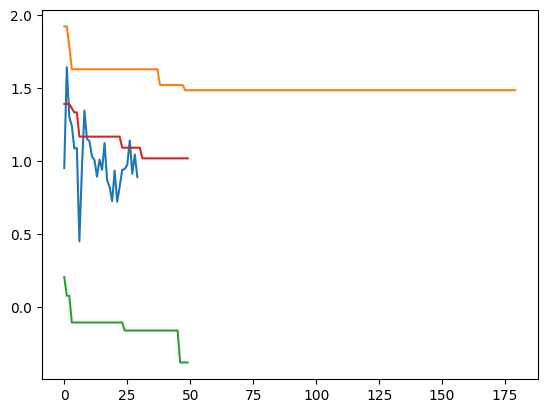

In [1706]:
plt.plot(history_GA)
plt.plot(history_SA)
plt.plot(history_PSO)
plt.plot(history_ACO)

In [1715]:
# =========================================
# ใช้ผลลัพธ์จาก algorithm ที่ดีที่สุด = PSO
# =========================================

best_solution = best_PSO

# -----------------------------------------
# function สร้างตารางเดินรถ
# -----------------------------------------

def generate_schedule(route_name, route_stops, num_bus, cycle_time, start_time=7 * 60 + 30):
    """
    start_time = 07:00
    cycle_time = เวลาวิ่งครบ loop (minutes)
    """
    headway = cycle_time / num_bus
    segments = len(route_stops) - 1
    time_per_stop = cycle_time / segments

    schedules = []

    for bus_id in range(num_bus):
        depart_time = start_time + (bus_id * headway)

        stop_times = []

        for i, stop in enumerate(route_stops):
            arrival = depart_time + (i * time_per_stop)

            hour = int(arrival // 60)
            minute = int(arrival % 60)

            stop_times.append({
                "stop": stop,
                "time": f"{hour:02d}:{minute:02d}"
            })

        schedules.append({
            "bus": f"{route_name}-Bus-{bus_id + 1}",
            "schedule": stop_times
        })

    return schedules


# -----------------------------------------
# สร้าง schedule จาก PSO
# -----------------------------------------

all_schedules = []

for idx, route in enumerate(best_solution, start=1):

    route_name = f"Route-{route['route_id']}"
    route_stops = route["path"]
    num_bus = route["num_bus"]

    # คำนวณ cycle time จาก graph
    cycle_time = calculate_cycle_time(
        route_stops,
        G
    )

    schedule = generate_schedule(
        route_name=route_name,
        route_stops=route_stops,
        num_bus=num_bus,
        cycle_time=cycle_time,
        start_time=7 * 60 + 30   # 07:00
    )

    all_schedules.append({
        "route_id": route["route_id"],
        "path": route_stops,
        "num_bus": num_bus,
        "cycle_time": cycle_time,
        "schedule": schedule
    })

In [1716]:
# -----------------------------------------
# print ตารางเดินรถ
# -----------------------------------------

print("===== BUS SCHEDULE FROM BEST PSO =====\n")

with open("bus_schedule.txt", "w", encoding="utf-8") as f:
    for route_data in all_schedules:

        print(f"Route ID: {route_data['route_id']}")
        print(f"Path: {' -> '.join(route_data['path'])}")
        print(f"Num Bus: {route_data['num_bus']}")
        print(f"Cycle Time: {route_data['cycle_time']} min")
        print("-" * 50)

        for bus in route_data["schedule"]:

            f.write(bus["bus"] + "\n")

            for stop in bus["schedule"]:

                f.write(

                    f"   {stop['stop']:15} : {stop['time']}\n"

                )

            f.write("\n")

        f.write("=" * 70 + "\n")

===== BUS SCHEDULE FROM BEST PSO =====

Route ID: 5
Path: Dorm -> Lecture -> Social -> Convention -> Dorm
Num Bus: 4
Cycle Time: 23 min
--------------------------------------------------


14

27

27

27

...

27

27

27

1

71